# Visualization with bvhplot

pybvh includes a built-in visualization module called `bvhplot`. It provides quick-look tools for inspecting BVH motion data without friction — one function call to see the skeleton.

This tutorial covers all of `bvhplot`'s capabilities. **Static plots** (`rest_pose`, `frame`, `trajectory`) always use matplotlib, which is always available. **Video rendering** (`render`) and **interactive playback** (`play`) automatically select the fastest backend available — matplotlib is the universal fallback, but when OpenCV, vedo, or k3d are installed, pybvh uses them transparently. The last section of the tutorial details those optional backends and how to install them.

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

import pybvh
from pybvh import bvhplot
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
bvh_folder = REPO_ROOT / "bvh_data"
output_folder = Path('./output')
output_folder.mkdir(exist_ok=True)

bvh = pybvh.read_bvh_file(bvh_folder / 'bvh_test1.bvh')
print(bvh)

24 elements in the Hierarchy, 75 frames at 30.0 fps (frame_time=0.033333s)


## A note on the API

All visualization functions live in the `pybvh.bvhplot` module. For convenience, they're also available as **wrapper methods** on the `Bvh` class:

| Use case | API style |
|---|---|
| Single skeleton | `bvh.plot_frame()`, `bvh.render()`, etc. | (recommended — more intuitive) |
| Multiple skeletons (side-by-side) | `bvhplot.frame([bvh1, bvh2], ...)` | (required — designed for lists) |

In this tutorial, we use `bvh.method()` for single-object operations to keep the code clean and intuitive. We switch to `bvhplot.function()` when comparing multiple skeletons, since those functions are designed to handle lists.

Both approaches call the same underlying code — use whichever fits your workflow.

# What are the visualizations for?

pybvh proposes the following visualization tools, adapted to different needs:

| What you want to know | Tool | Output |
|---|---|---|
| What does the skeleton look like | rest_pose() | Static rest pose (all joint angles zero) |
| What's the pose at frame N? | frame(frame=N) | Static pose at a specific moment |
| What does the motion look like over time? | play() or render() | Animated sequence |
| Does the character walk in a straight line? | trajectory() | 2D top-down root path |

This section covers all of these. Most workflows start with rest_pose() or frame() to sanity-check the skeleton, then move to play() for exploration or render() to export results.

# Static snapshots

## Viewing the rest pose

The rest pose (also called bind pose) is the skeleton's shape when all joint angles are zero. Only the bone offsets define the posture. It's the first thing to check: does the skeleton look right?

Use bvhplot.rest_pose() to display it.

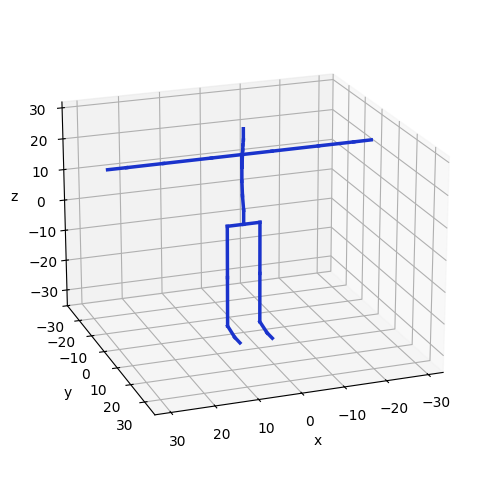

In [2]:
fig, ax = bvh.plot_rest_pose()
plt.show()

## Viewing a single frame

bvhplot.frame() plots the skeleton at a specific frame of the animation. This is useful for inspecting the pose at a moment in time.

Pass the frame index (0-based) as the frame parameter:

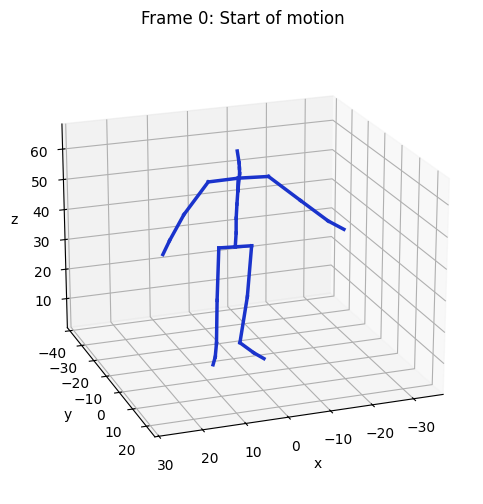

In [3]:
# Early frame
fig, ax = bvh.plot_frame(frame=0)
ax.set_title('Frame 0: Start of motion')
plt.show()

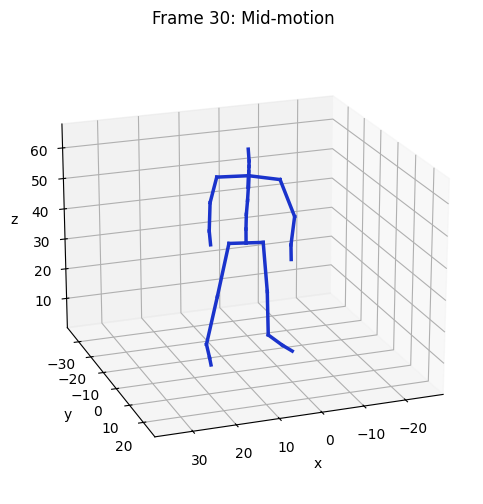

In [4]:
# Mid-motion frame
fig, ax = bvh.plot_frame(frame=30)
ax.set_title('Frame 30: Mid-motion')
plt.show()

## Camera control

Both `rest_pose()` and `frame()` accept a `camera` parameter to control the viewing angle. You can use preset strings or a custom `(azimuth, elevation)` tuple in degrees.

**Presets** — these auto-orient to the skeleton (pybvh detects which axis is up and which is forward from the BVH hierarchy, so they work regardless of whether the file is Y-up or Z-up):
- `'front'` — face the skeleton from the front
- `'side'` — rotated 90° from front
- `'top'` — bird's-eye view, looking down the up axis

**Custom angles** — a tuple `(azimuth, elevation)` in degrees, passed directly to matplotlib's `view_init()`. The vertical axis is the skeleton's detected up axis. These follow matplotlib's convention, so the exact values don't correspond to an intuitive "front = 0°" — use the presets when you want a specific named view, and custom angles only for fine-tuning (e.g. a slight tilt from `'front'`).

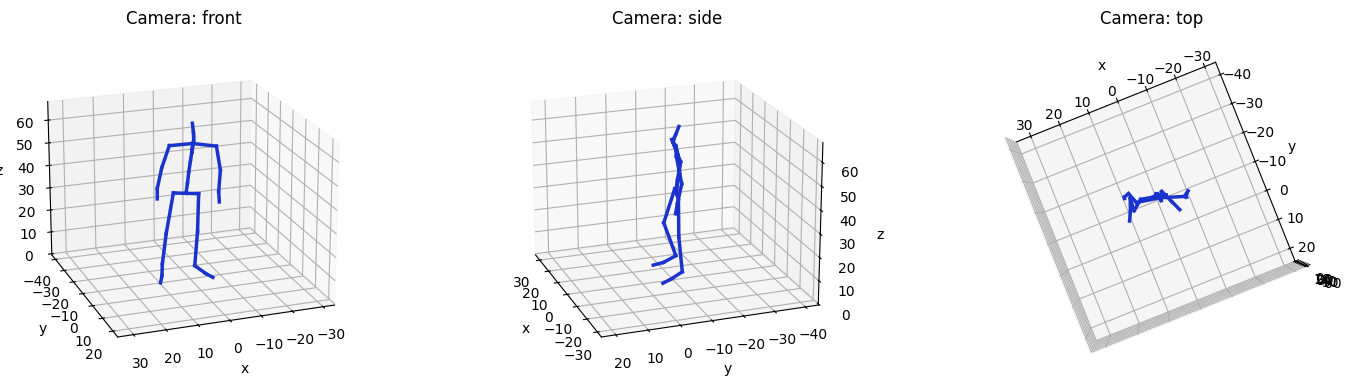

In [5]:
# Compare the same frame from different camera angles
frame_num = 20

fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': '3d'})

for ax, angle in zip(axes, ['front', 'side', 'top']):
    bvh.plot_frame(frame=frame_num, camera=angle, ax=ax)
    ax.set_title(f'Camera: {angle}')

plt.tight_layout()
plt.show()

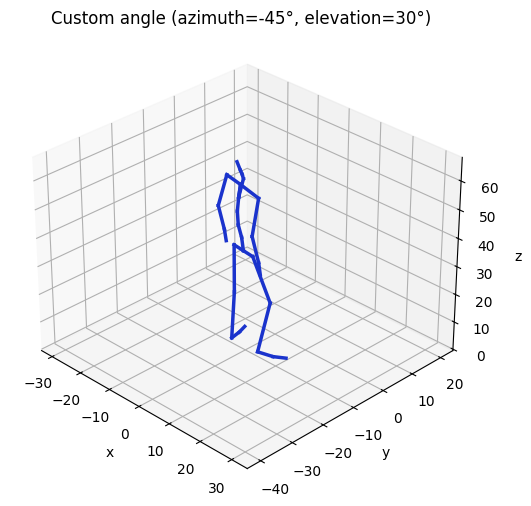

In [6]:
# Custom angle
azimuth, elevation = -45, 30
fig, ax = bvh.plot_frame(frame=20, camera=(azimuth, elevation))
ax.set_title(f'Custom angle (azimuth={azimuth}°, elevation={elevation}°)')
plt.show()

## Side-by-side comparison

All bvhplot functions accept a list of Bvh objects to display multiple skeletons side by side. Use the labels parameter to title each subplot.

This is useful for comparing different skeletons or the same motion with different transformations.

/home/victor/projects/pybvh/pybvh/bvh.py:122: UserWarning: Rest pose suggests world up is '+y' but the first 
animation frame's head-hips direction is closer to '+z'. 
Using '+z' from the animation data. If this is wrong 
for your file, set it explicitly via `bvh.world_up = '<axis>'`.
  self._world_up_cached = _infer_world_up(self, warn=_warn_world_up)


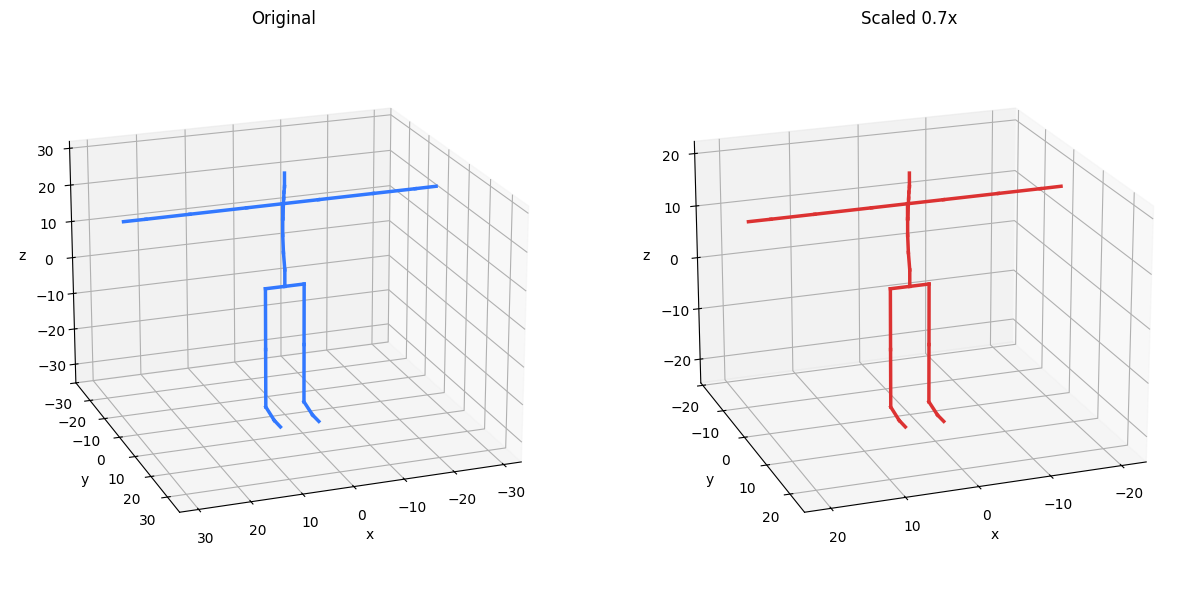

In [7]:
# Load a second skeleton for comparison
bvh2 = pybvh.read_bvh_file(bvh_folder / 'bvh_test3.bvh')
bvh_small = bvh.scale(0.7)

fig, axes = bvhplot.rest_pose([bvh, bvh_small], labels=['Original', 'Scaled 0.7x'])
plt.tight_layout()
plt.show()

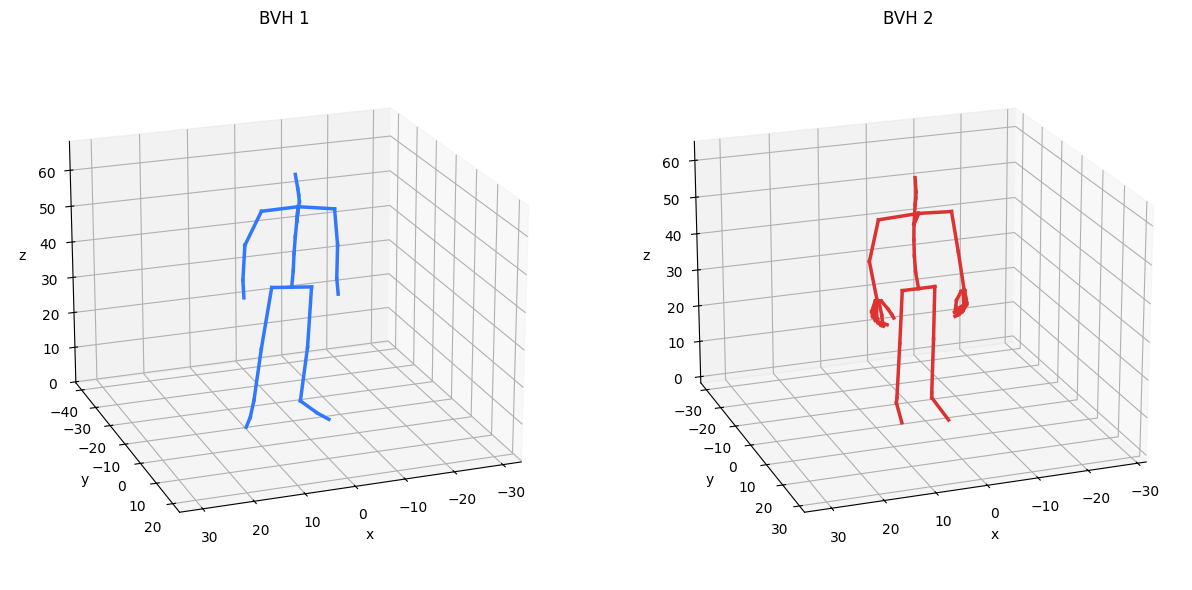

In [8]:
# Compare the same frame from two different skeletons
fig, axes = bvhplot.frame([bvh, bvh2], frame=15, labels=['BVH 1', 'BVH 2'])
plt.tight_layout()
plt.show()

# Centering modes

All visualization functions accept a `centered` parameter — the same centering modes as `node_positions()` (see Tutorial 2 for a full explanation):

- `'world'` (default): absolute positions from the BVH file.
- `'first'`: first frame's root over the origin (horizontal axes only, original height kept), motion continues from there.
- `'skeleton'`: root at the origin in every frame (pose only, no global movement).

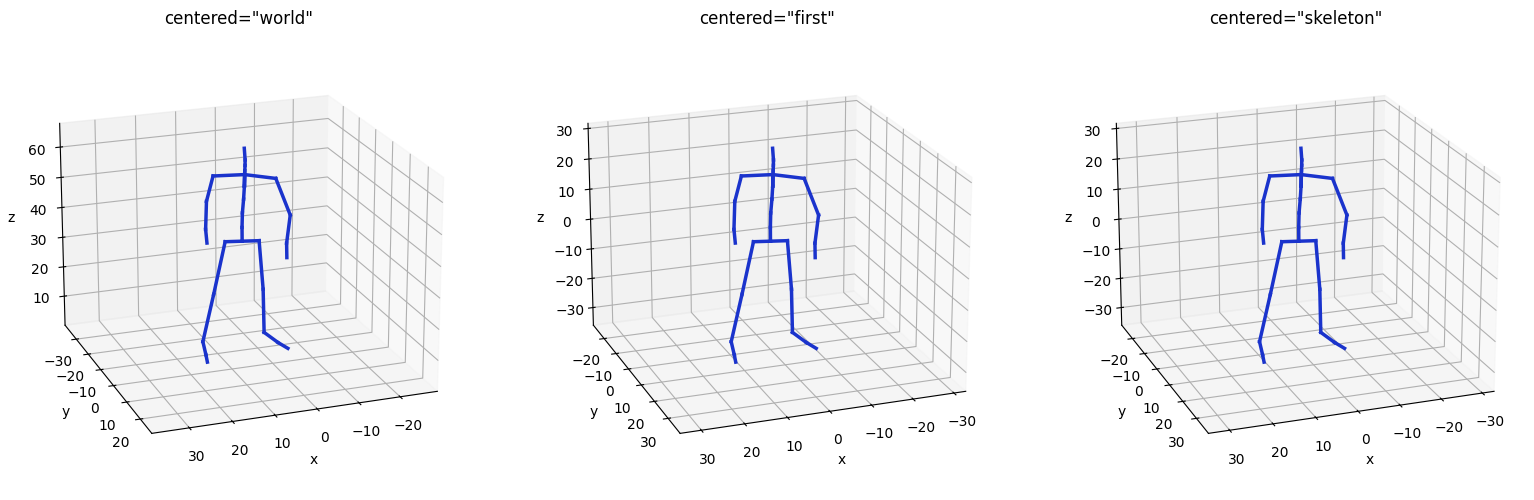

In [9]:
# Side-by-side frame plots — axis tick values reveal the centering difference
fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={'projection': '3d'})

for ax, mode in zip(axes, ['world', 'first', 'skeleton']):
    bvh.plot_frame(frame=30, centered=mode, ax=ax)
    ax.set_title(f'centered="{mode}"')

plt.tight_layout()
plt.show()

# Root trajectory

The root trajectory is the path the skeleton's root joint (typically the hips) traces across the ground plane over the animation.

This is useful for understanding the overall motion pattern: Is the character walking in a straight line? Turning in circles? Standing still?

`bvhplot.trajectory()` shows a 2D top-down view of the root's path.

> **A note on orientation.** Trajectory plots follow **map convention** — the world's forward direction (typically `+Y`) points **up on the plot**, like north on a map. This differs from the 3D `camera='front'` view earlier in this tutorial, which positions the camera in front of the character so their face points *out of the screen toward you*. Same world direction, different on-screen direction: it's the standard top-down-vs-camera split, not an inconsistency.

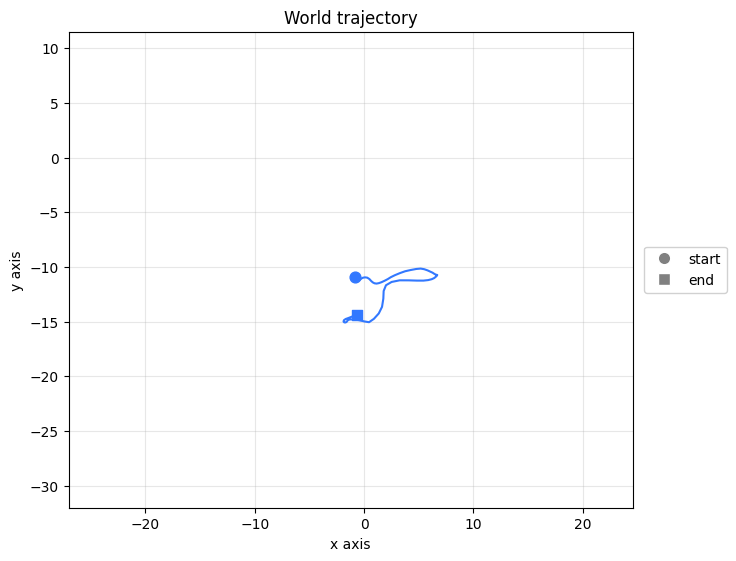

In [10]:
# Absolute trajectory
fig, ax = bvh.plot_trajectory(centered='world')
ax.set_title('World trajectory')
plt.show()

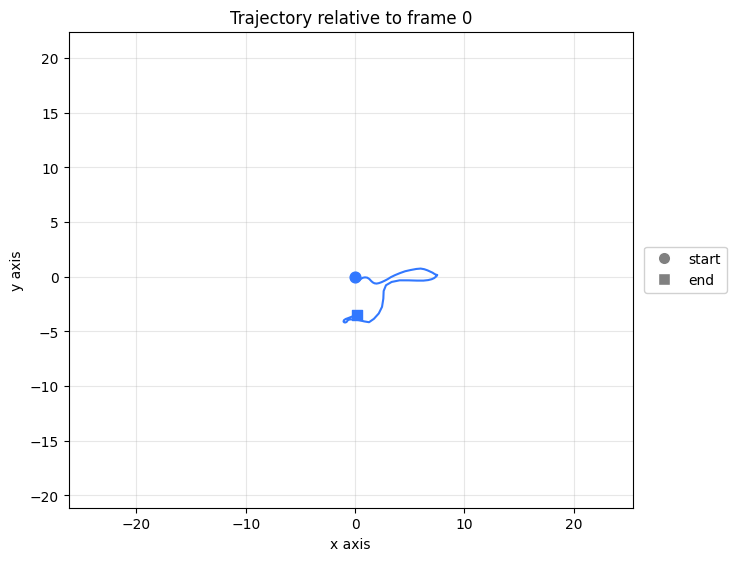

In [11]:
# Relative to first frame
fig, ax = bvh.plot_trajectory(centered='first')
ax.set_title('Trajectory relative to frame 0')
plt.show()

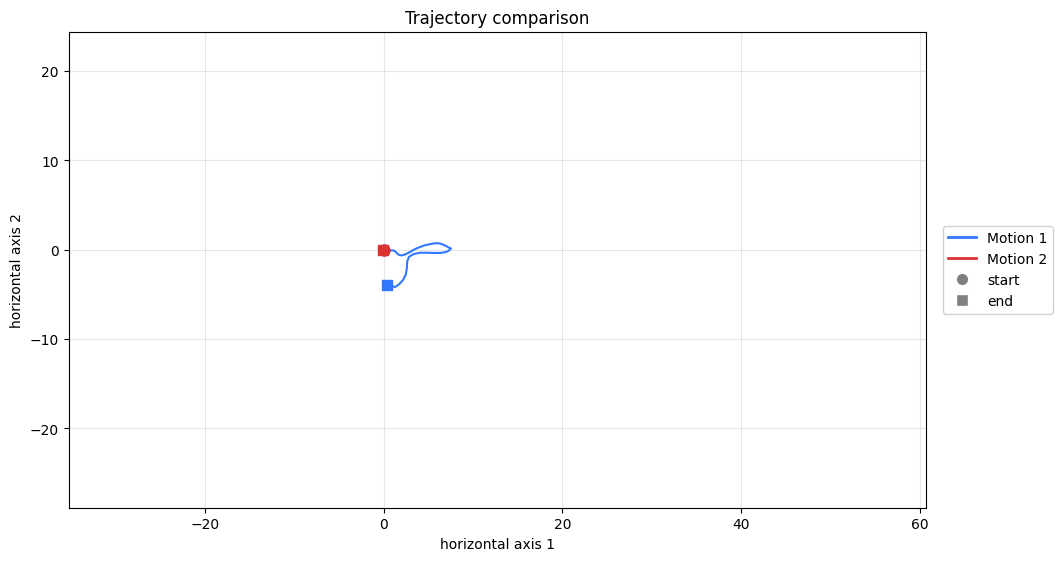

In [12]:
# Compare multiple trajectories
bvh2 = pybvh.read_bvh_file(bvh_folder / 'bvh_test2.bvh')

fig, ax = bvhplot.trajectory([bvh, bvh2], labels=['Motion 1', 'Motion 2'], centered='first')
ax.set_title('Trajectory comparison')
plt.show()

# Video and animation export

To export an animation to a file, use bvhplot.render(). This is especially useful for sharing results, including in papers or presentations.

The output format is inferred from the file extension. Supported formats include .mp4, .gif, .webp, .mov, .avi, and .html.

Rendered files are saved to the output/ folder in the tutorials directory.

## A note on backends

`render()` supports two backends:
- **`'opencv'`** — fast rendering (~100x faster than matplotlib). Requires `pip install pybvh[opencv]`.
- **`'matplotlib'`** — always available, no extra dependencies.

By default (`backend='auto'`), OpenCV is used if installed, otherwise matplotlib. All the examples below use the auto default, so the same code runs on any install — it's just faster if you have OpenCV. The `resolution` parameter (e.g. `(1920, 1080)`) only applies to the OpenCV backend.

## Basic rendering

In [13]:
# Export to MP4
output_path = bvh.render(output_folder / 'bvh_animation.mp4')
print(f'Animation saved to: {output_path}')

Animation saved to: output/bvh_animation.mp4


In [14]:
# Export to GIF (smaller file, good for web/README)
output_path = bvh.render(output_folder / 'bvh_animation.gif', fps=15)
print(f'GIF saved to: {output_path}')

GIF saved to: output/bvh_animation.gif


## Render options

In [15]:
output_path = bvh.render(
    output_folder / 'bvh_animation_custom.mp4',
    camera='side',
    fps=30,
    show_axis=True,
)
print(f'Animation with options saved to: {output_path}')

Animation with options saved to: output/bvh_animation_custom.mp4


## Camera tracking: `follow=True`

By default the camera is stable — it's pointed at the skeleton once from the first frame's orientation and stays there for the whole clip. If the character turns during the animation, you see them rotate in view (which is usually what you want for spatial awareness).

For characters that rotate significantly, you can ask the camera to **track the character's facing direction**, so the view always shows them from the same (e.g. front) angle:

```python
bvh.render('walk.mp4', follow=True)
```

With this option, the character always face the viewer while the world orbits around them.

`follow=True` only makes sense with preset cameras (`'front'`, `'side'`, `'top'`). A custom `(azim, elev)` tuple is a fixed camera — `follow` is a silent no-op in that case.

In [16]:
# Render with follow=True — camera tracks the character's facing direction.
# For this particular clip the character doesn't rotate much, so the effect
# is subtle; try it on a clip where the character turns.
output_path = bvh.render(
    output_folder / 'bvh_animation_follow.mp4',
    camera='front',
    follow=True,
)
print(f'Follow-mode animation saved to: {output_path}')

Follow-mode animation saved to: output/bvh_animation_follow.mp4


## Side-by-side video

Just like static plots, you can render multiple skeletons side by side. The sync parameter controls behavior when clips have different lengths:
- 'truncate' (default): stop at the shortest clip
- 'pad': pad shorter clips by freezing on their last frame

In [17]:
bvh2 = pybvh.read_bvh_file(bvh_folder / 'bvh_test2.bvh')

output_path = bvhplot.render(
    [bvh, bvh2],
    output_folder / 'comparison.mp4',
    labels=['Original', 'Other skeleton'],
    sync='pad',
    match_fps="highest"
)
print(f'Comparison video saved to: {output_path}')

Comparison video saved to: output/comparison.mp4


# Interactive playback

bvhplot.play() provides interactive animation playback. It auto-detects the best backend available for your environment:
- k3d (Jupyter widget) — if in Jupyter with k3d installed, interactive 3D widget
- vedo (desktop window) — if installed, full 3D interactive viewer
- matplotlib (fallback) — always available, but less interactive

In [18]:
# This auto-detects the best backend
# falls back to matplotlib if k3d not installed
bvh.play()

In [19]:
# Play multiple skeletons side by side
bvh2 = pybvh.read_bvh_file(bvh_folder / 'bvh_test2.bvh')
bvhplot.play([bvh, bvh2], labels=['Motion 1', 'Motion 2'], centered='first', sync="pad")

/tmp/ipykernel_2136275/386220029.py:3: UserWarning: Frame rates differ across clips (30.0, 120.0 fps). 
Playback speed will not match real time for all clips. 
Use match_fps='lowest' or match_fps='highest' to resample 
automatically, or call bvh.resample(target_fps) manually.
  bvhplot.play([bvh, bvh2], labels=['Motion 1', 'Motion 2'], centered='first', sync="pad")
/tmp/ipykernel_2136275/386220029.py:3: UserWarning: Clips have different world_up values (+z, +y). 
Use pybvh.reorient_world_up() to normalize before comparing.
  bvhplot.play([bvh, bvh2], labels=['Motion 1', 'Motion 2'], centered='first', sync="pad")


The previous cell triggers two warnings: the clips have different frame rates (30 fps vs 120 fps) and different world_up conventions (`+z` for Motion 1, `+y` for Motion 2). The cell below addresses both: `reorient_world_up()` aligns the coordinate systems, `match_fps` resamples to a common frame rate, and `sync="pad"` extends the shorter clip rather than truncating the longer one.

In [20]:
bvh2_zup = bvh2.reorient_world_up("+z")

bvhplot.play([bvh, bvh2_zup], labels=['Motion 1', 'Motion 2'],
                    centered='first',
                    match_fps="highest",
                    sync="pad"
                    )

# Interactive backends (optional)

pybvh supports optional visualization backends that provide faster rendering or richer interactive viewports. When installed, `render()` and `play()` use them automatically; this section details each one and how to install it.

## Available backends

| Backend | Environment | Install | Best for |
|---------|------------|---------|----------|
| matplotlib | Any | *(included)* | Static plots, universal fallback |
| OpenCV | Any | `pip install pybvh[opencv]` | Fast video rendering (~100x faster) |
| vedo | Desktop | `pip install pybvh[viewer]` | Interactive 3D desktop viewer |
| k3d | Jupyter | `pip install pybvh[interactive]` | Jupyter interactive 3D widget |

## Desktop viewer with vedo

The vedo backend opens a full 3D window with keyboard controls:

The quality parameter controls visual quality:
- 'high' (default) — 3D tubes and spheres with lighting
- 'fast' — flat lines and points for maximum performance

In [21]:
# Only works if vedo is installed: pip install pybvh[viewer]
# Uncomment to try (this will not work on remote/headless notebook):
# bvh.play(backend='vedo', quality='high')

## Jupyter playback with k3d

In Jupyter notebooks, the k3d backend renders an interactive 3D widget directly in the cell output. You can rotate, zoom, and scrub through the animation.

In [22]:
# Only works in Jupyter with k3d installed: pip install pybvh[interactive]
# Uncomment to try:
# bvh.play(backend='k3d')

# Summary

| Function | Purpose | Returns |
|---|---|---|
| bvhplot.rest_pose(bvh) | Static T-pose | (Figure, Axes) |
| bvhplot.frame(bvh, frame=N) | Static frame | (Figure, Axes) |
| bvhplot.trajectory(bvh) | 2D root path | (Figure, Axes) |
| bvhplot.render(bvh, path) | Export animation to file | Path |
| bvhplot.play(bvh) | Interactive playback | backend-specific |

All functions accept Bvh | list[Bvh], and support centered, camera, and labels parameters. The optional backends (vedo, k3d, OpenCV) provide richer playback and faster rendering when installed.

For the full parameter reference, see the API documentation.